**### Import The necessary library##**

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [247]:
###Read the dataset
df = pd.read_csv("/content/nba_final.csv")

In [248]:
df

,Rk,Player.x,Player_ID,Pos1,Pos2,Age,Tm,G,GS,MP,...,Conference,Role,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score,Play
0,170,A.J. Hammons,hammoaj01,C,NaN,24,DAL,22,0,7.4,...,West,Front,786,123,NaN,NaN,NaN,NaN,83.5,No
1,58,Aaron Brooks,brookaa01,PG,NaN,32,IND,65,0,13.8,...,Est,Back,2474,64,NaN,NaN,NaN,NaN,48.2,No
2,157,Aaron Gordon,gordoaa01,SF,NaN,21,ORL,80,72,28.7,...,Est,Front,22774,29,NaN,NaN,NaN,NaN,40.0,No
3,352,Adreian Payne,paynead01,PF,NaN,25,MIN,18,0,7.5,...,West,Front,861,120,1.0,52.0,NaN,NaN,75.5,No
4,10,Al-Farouq Aminu,aminual01,PF,NaN,26,POR,61,25,29.1,...,West,Front,4971,69,7.0,23.0,NaN,NaN,42.8,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,109,Zach Collins,colliza01,C,NaN,21,POR,77,0,17.6,...,West,Front,16287,74,1.0,52.0,0.0,8.0,86.8,No
1404,294,Zach LaVine,lavinza01,SG,NaN,23,CHI,63,62,34.5,...,Est,Back,519746,7,17.0,8.0,0.0,8.0,36.5,No
1405,308,Zach Lofton,loftoza01,SG,NaN,26,DET,1,0,4.0,...,Est,Back,136,114,0.0,61.0,0.0,8.0,132.2,No
1406,393,Zaza Pachulia,pachuza01,C,NaN,34,DET,68,3,12.9,...,Est,Front,21525,50,2.0,41.0,0.0,7.0,69.8,No


In [249]:
## check the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1408 entries, 0 to 1407
Data columns (total 45 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rk          1408 non-null   int64  
 1   Player.x    1408 non-null   object 
 2   Player_ID   1408 non-null   object 
 3   Pos1        1408 non-null   object 
 4   Pos2        12 non-null     object 
 5   Age         1408 non-null   int64  
 6   Tm          1408 non-null   object 
 7   G           1408 non-null   int64  
 8   GS          1408 non-null   int64  
 9   MP          1408 non-null   float64
 10  FG          1408 non-null   float64
 11  FGA         1408 non-null   float64
 12  FG.         1404 non-null   float64
 13  X3P         1408 non-null   float64
 14  X3PA        1408 non-null   float64
 15  X3P.        1309 non-null   float64
 16  X2P         1408 non-null   float64
 17  X2PA        1408 non-null   float64
 18  X2P.        1393 non-null   float64
 19  eFG.        1404 non-null  

**we check the datatypes to verify whether each column has the correct datatype or not and also to know wether there are any object columns which we need to encode**

In [250]:
df.isnull().sum(axis = 0)## print the total number of missing values column wise

,0
Rk,0
Player.x,0
Player_ID,0
Pos1,0
Pos2,1396
Age,0
Tm,0
G,0
GS,0
MP,0


In [251]:
df.isnull().sum(axis = 1) ## print the total number of missing values columns wise

,0
0,6
1,5
2,5
3,3
4,3
...,...
1403,1
1404,1
1405,4
1406,1


In [252]:
df.isnull().sum(axis = 1) > 4 # mark the rows as true if they fulfill the mentioned conditioned and false otherwise

,0
0,True
1,True
2,True
3,False
4,False
...,...
1403,False
1404,False
1405,False
1406,False


In [253]:
df[df.isnull().sum(axis = 1) > 5] ## print the rows which have more than 5 missing values

,Rk,Player.x,Player_ID,Pos1,Pos2,Age,Tm,G,GS,MP,...,Conference,Role,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score,Play
0,170,A.J. Hammons,hammoaj01,C,NaN,24,DAL,22,0,7.4,...,West,Front,786,123,NaN,NaN,NaN,NaN,83.5,No
16,443,Anderson Varejão,varejan01,C,NaN,34,GSW,14,1,6.6,...,West,Front,1724,40,NaN,NaN,NaN,NaN,42.0,No
27,341,Arinze Onuaku,onuakar01,C,NaN,29,ORL,8,0,3.5,...,Est,Front,216,129,NaN,NaN,NaN,NaN,90.0,No
37,60,Bobby Brown,brownbo02,PG,NaN,32,HOU,25,0,4.9,...,West,Back,206,70,NaN,NaN,NaN,NaN,52.0,No
48,378,Brian Roberts,roberbr01,PG,NaN,31,CHO,41,2,10.1,...,Est,Back,484,91,NaN,NaN,NaN,NaN,61.8,No
51,67,Bruno Caboclo,cabocbr01,SF,NaN,21,TOR,9,0,4.4,...,Est,Front,5185,66,NaN,NaN,NaN,NaN,58.5,No
54,302,C.J. Miles,milescj01,SF,NaN,29,IND,76,29,23.4,...,Est,Front,1965,95,NaN,NaN,NaN,NaN,73.0,No
55,455,C.J. Watson,watsocj01,PG,NaN,32,ORL,62,9,16.3,...,Est,Back,369,92,NaN,NaN,NaN,NaN,62.2,No
56,463,C.J. Wilcox,wilcocj01,SG,NaN,26,ORL,22,0,4.9,...,Est,Back,287,93,NaN,NaN,NaN,NaN,62.8,No
62,109,Cheick Diallo,diallch01,PF,NaN,20,NOP,17,0,11.7,...,West,Front,877,119,NaN,NaN,NaN,NaN,81.5,No


In [254]:
df = df[df.isnull().sum(axis = 1) <= 5 ] ## filter out rows which has more than 5 missing values


In [255]:
df.shape

(1371, 45)

In [256]:
df

,Rk,Player.x,Player_ID,Pos1,Pos2,Age,Tm,G,GS,MP,...,Conference,Role,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score,Play
1,58,Aaron Brooks,brookaa01,PG,NaN,32,IND,65,0,13.8,...,Est,Back,2474,64,NaN,NaN,NaN,NaN,48.2,No
2,157,Aaron Gordon,gordoaa01,SF,NaN,21,ORL,80,72,28.7,...,Est,Front,22774,29,NaN,NaN,NaN,NaN,40.0,No
3,352,Adreian Payne,paynead01,PF,NaN,25,MIN,18,0,7.5,...,West,Front,861,120,1.0,52.0,NaN,NaN,75.5,No
4,10,Al-Farouq Aminu,aminual01,PF,NaN,26,POR,61,25,29.1,...,West,Front,4971,69,7.0,23.0,NaN,NaN,42.8,No
5,203,Al Horford,horfoal01,C,NaN,30,BOS,68,68,32.3,...,Est,Front,12219,14,8.0,16.0,2.0,6.0,12.5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,109,Zach Collins,colliza01,C,NaN,21,POR,77,0,17.6,...,West,Front,16287,74,1.0,52.0,0.0,8.0,86.8,No
1404,294,Zach LaVine,lavinza01,SG,NaN,23,CHI,63,62,34.5,...,Est,Back,519746,7,17.0,8.0,0.0,8.0,36.5,No
1405,308,Zach Lofton,loftoza01,SG,NaN,26,DET,1,0,4.0,...,Est,Back,136,114,0.0,61.0,0.0,8.0,132.2,No
1406,393,Zaza Pachulia,pachuza01,C,NaN,34,DET,68,3,12.9,...,Est,Front,21525,50,2.0,41.0,0.0,7.0,69.8,No


In [257]:
df.isnull().sum()

,0
Rk,0
Player.x,0
Player_ID,0
Pos1,0
Pos2,1359
Age,0
Tm,0
G,0
GS,0
MP,0


In [258]:
df.fillna(0, inplace = True) ## fill the missing values with 0

/tmp/ipython-input-2624931828.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace = True) ## fill the missing values with 0


In [259]:
df.shape

(1371, 45)

In [260]:
## dropped the columnn pos2 as it has 95% null values
df.drop(columns=["Pos2"], inplace= True)

/tmp/ipython-input-688422556.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["Pos2"], inplace= True)


In [261]:
##Let's the duplicated
df.duplicated().sum()

np.int64(0)

In [262]:
##let's drop the duplicated values if any
df.drop_duplicates(inplace = True)

/tmp/ipython-input-1885114180.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace = True)


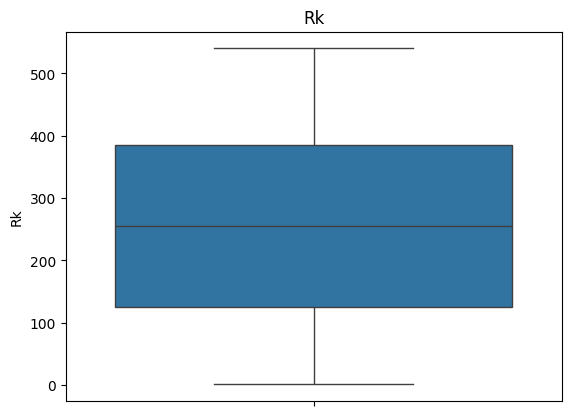

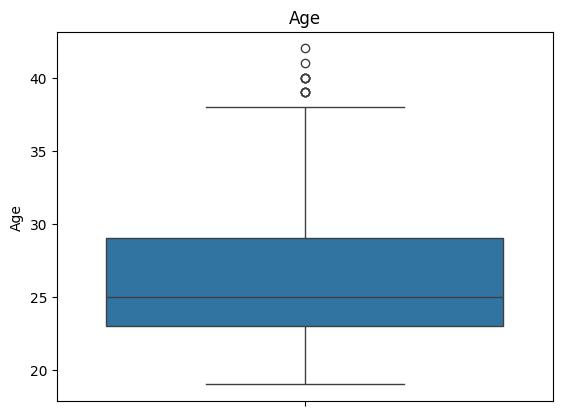

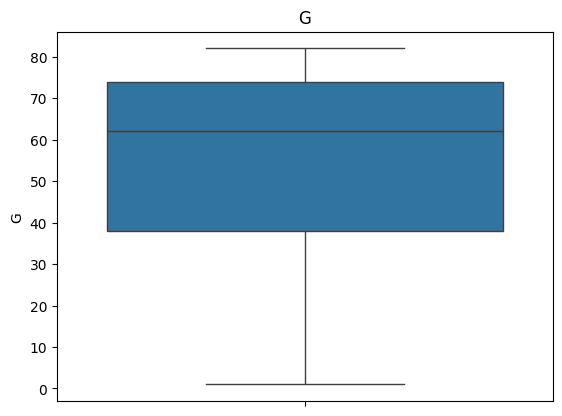

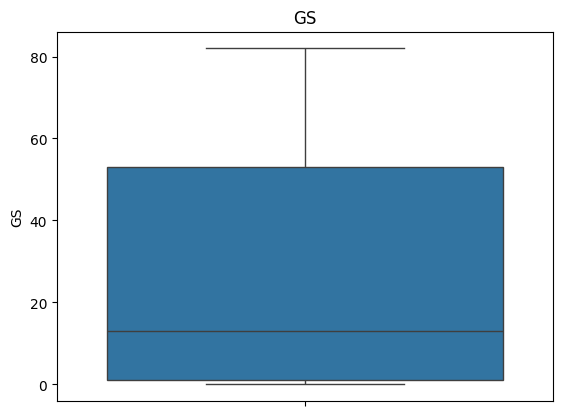

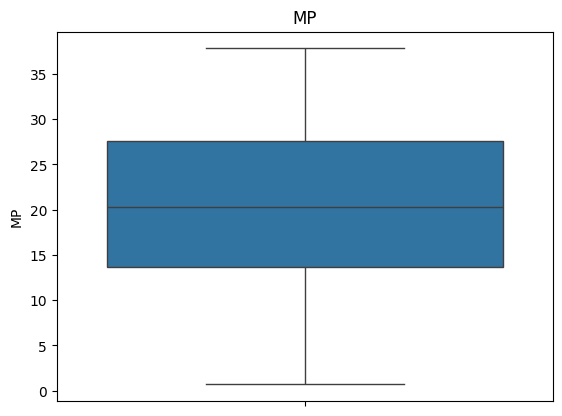

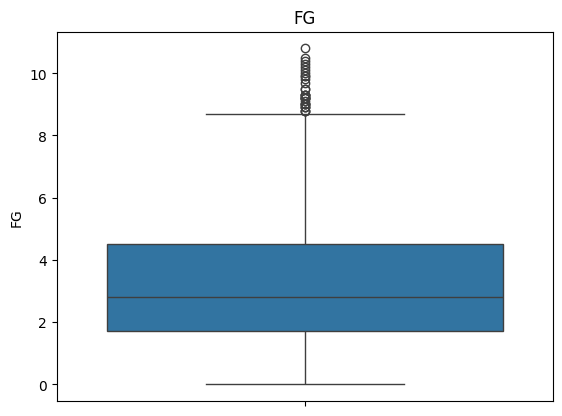

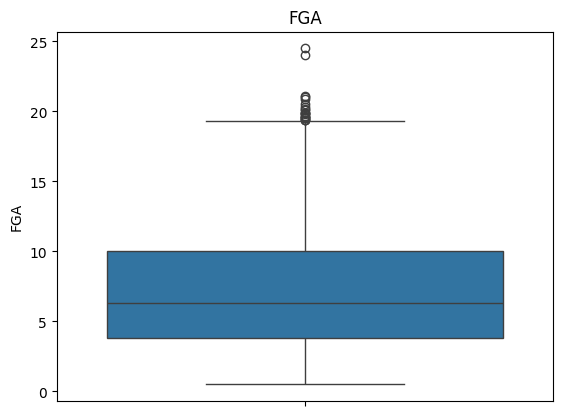

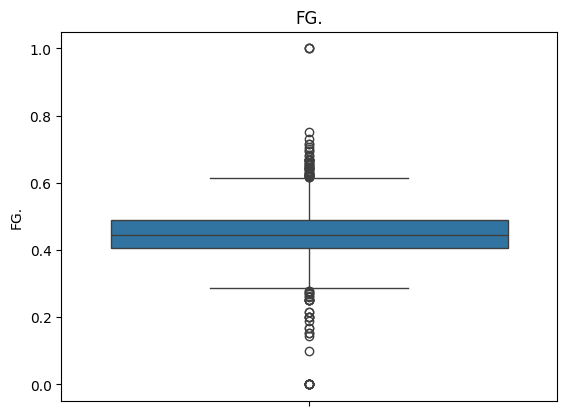

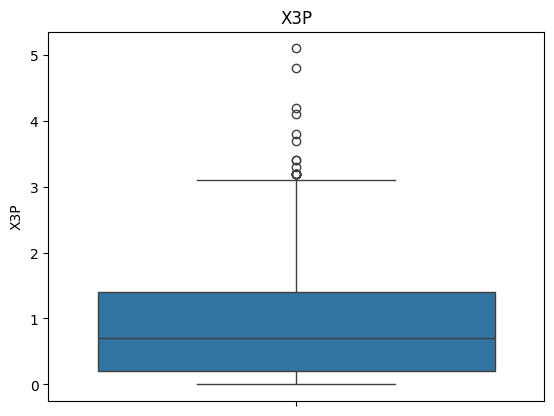

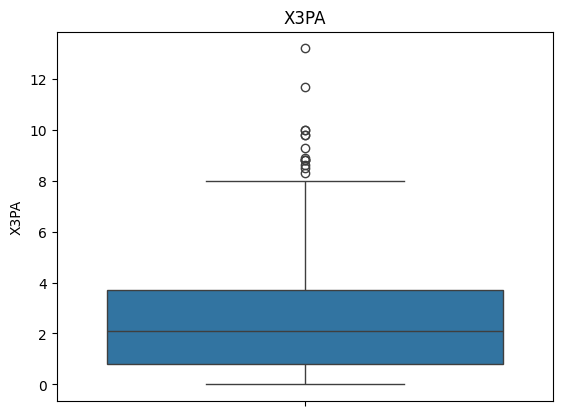

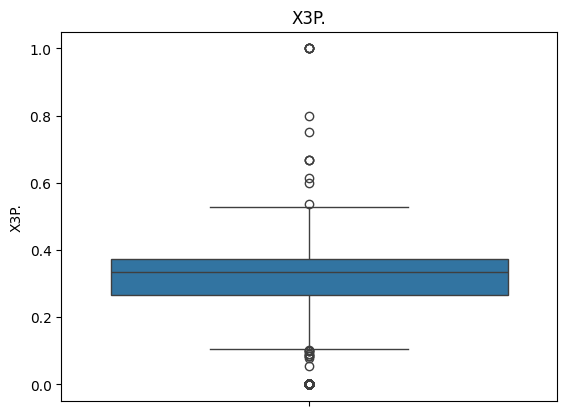

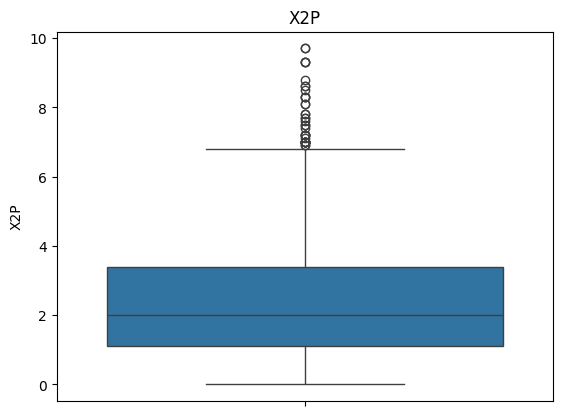

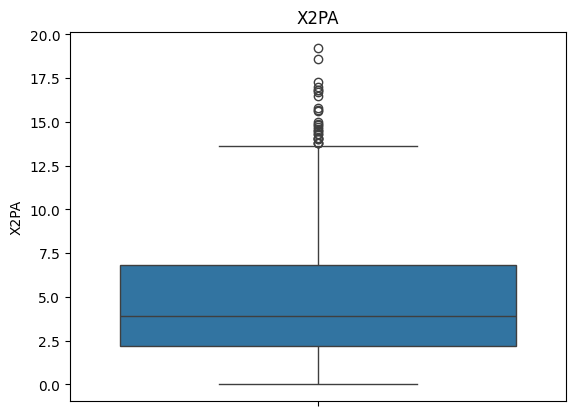

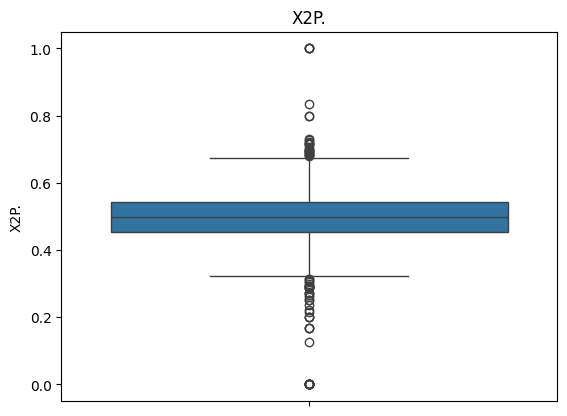

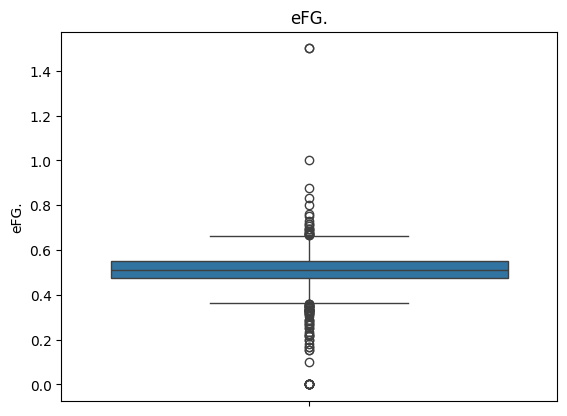

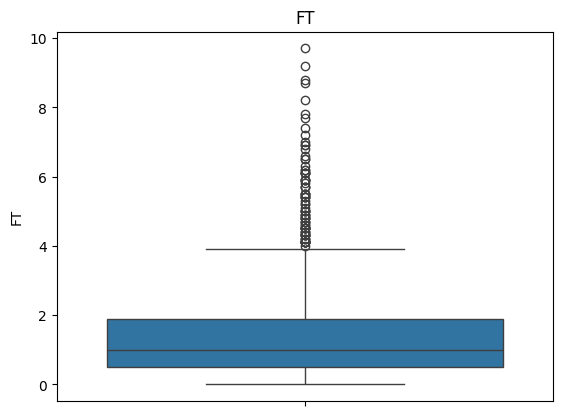

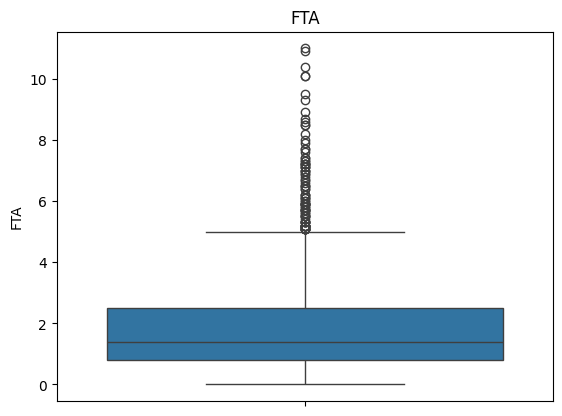

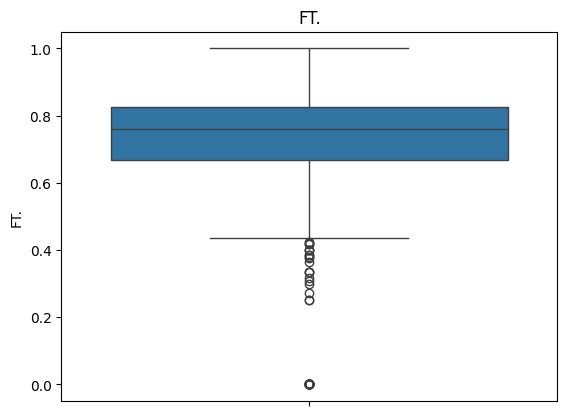

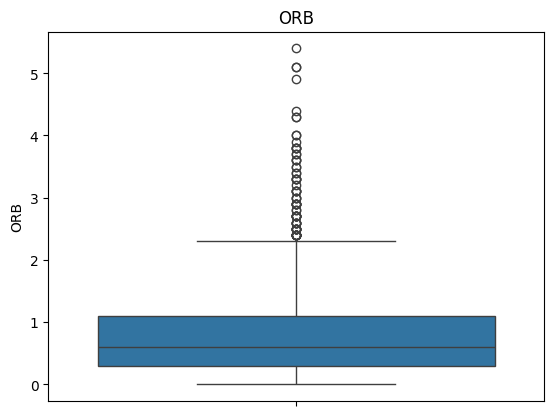

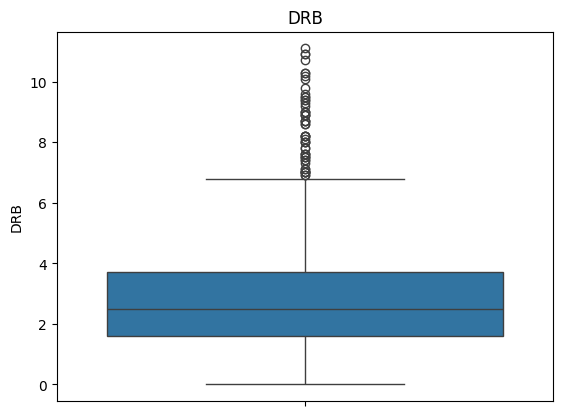

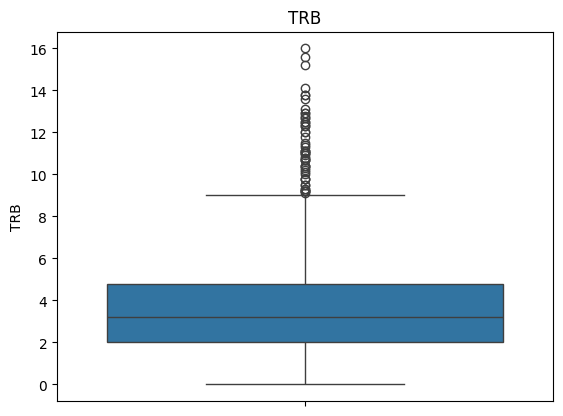

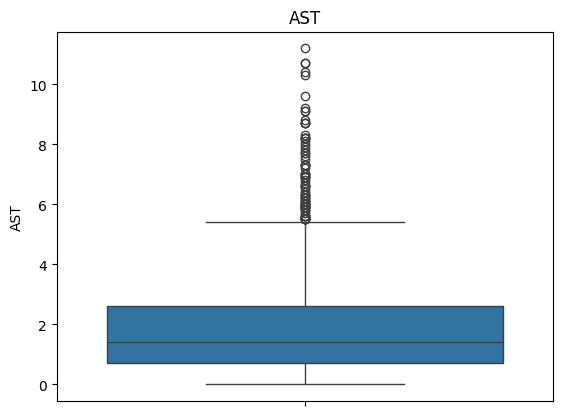

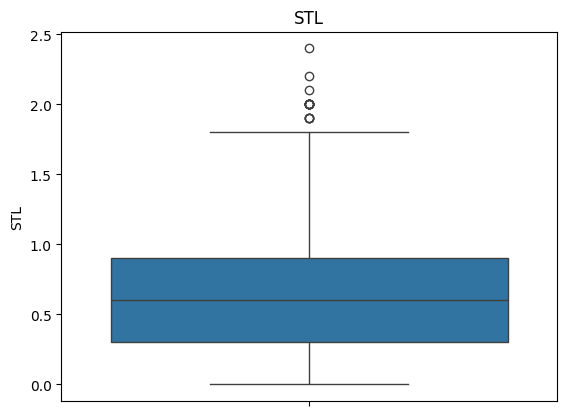

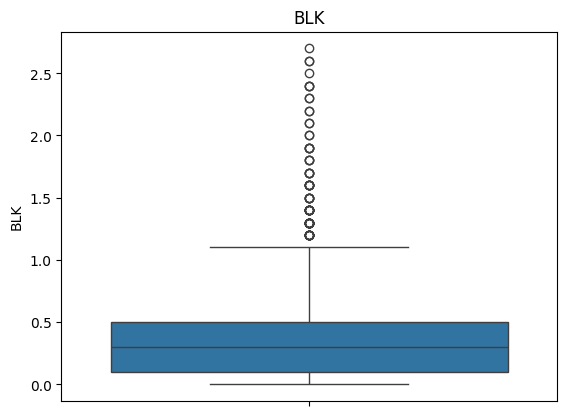

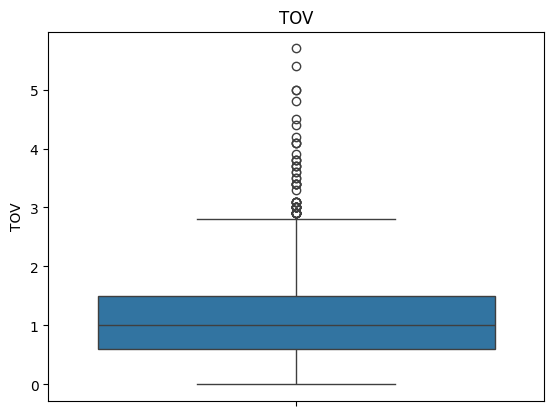

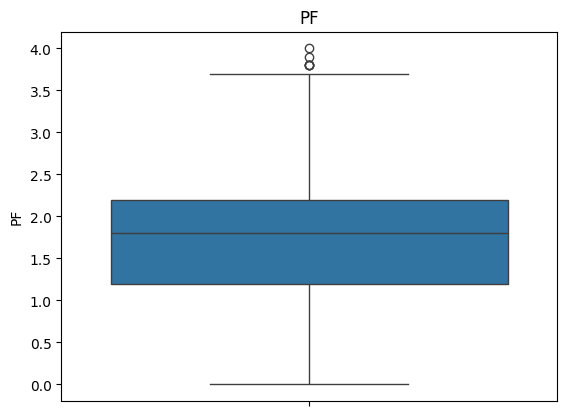

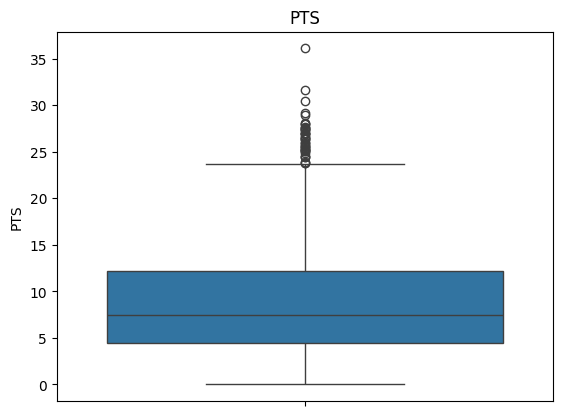

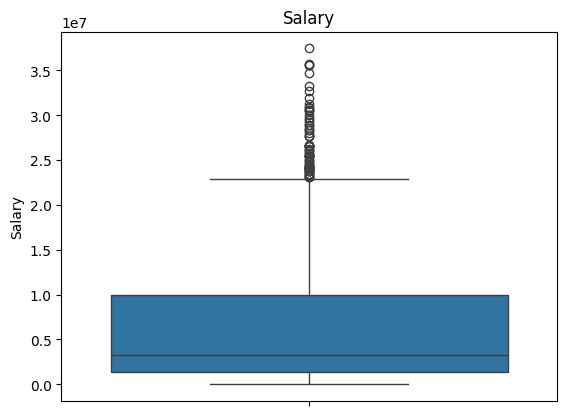

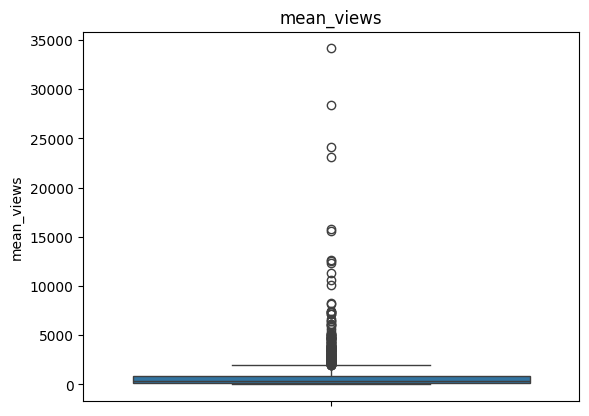

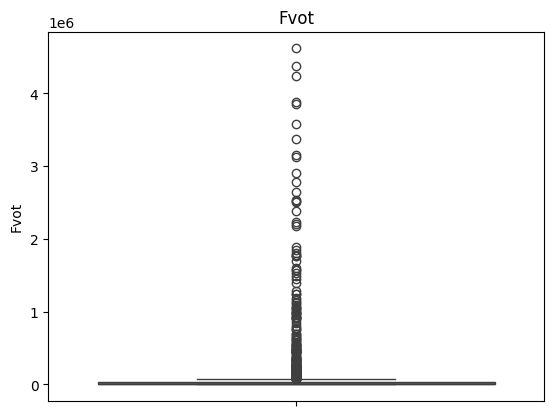

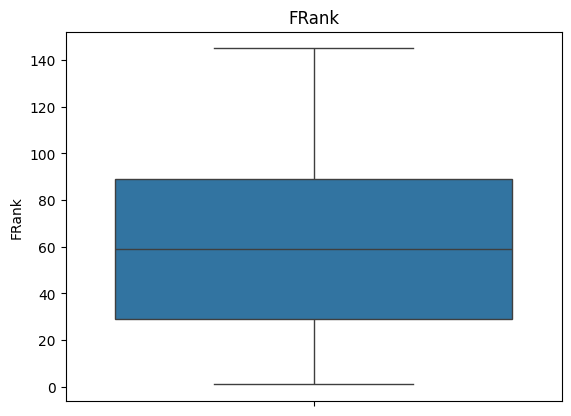

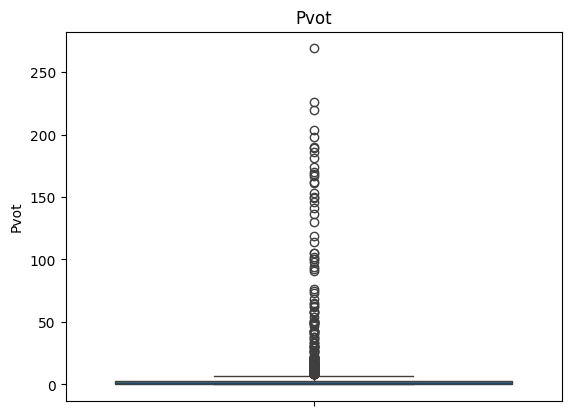

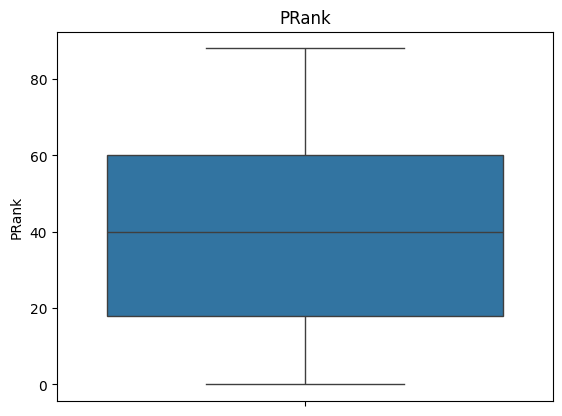

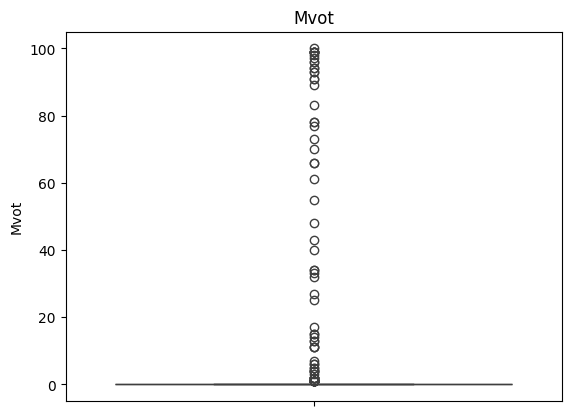

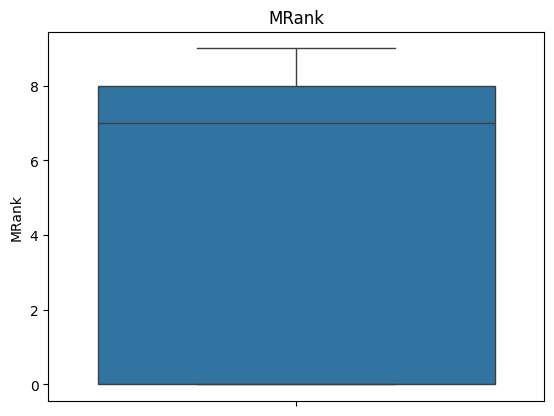

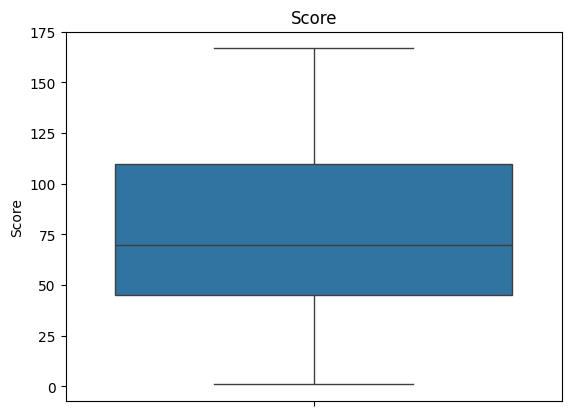

In [263]:
## Let the oulier// there no need of checking outliers
for i in df.columns:
  if df[i].dtypes != "object":
    sns.boxplot(df[i])
    plt.title(i)
    plt.show()

In [264]:
### let's  apply the label ecoder to change the catgorical columns to int
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [265]:
### Running a loop fpor this
for i in df.columns:
  if df[i].dtypes == "object":
    df[i] = le.fit_transform(df[i])

/tmp/ipython-input-2014438754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = le.fit_transform(df[i])
/tmp/ipython-input-2014438754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = le.fit_transform(df[i])
/tmp/ipython-input-2014438754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

In [266]:
# obj_cols = df.select_dtypes('object').columns #select the column names of the columns which are of the object type
# obj_cols

In [267]:
# for in in obj_cols:
#   df[col] = le.fit_transform(df[i])

In [268]:
### check for the data imbalance
df["Play"].value_counts()

,count
Play,
0,1298
1,73


**Model Buiding Process**

In [269]:
x = df.drop(columns = "Play") ## Store the input columns in x
y = df["Play"] # Store the output columns in y

In [270]:
##Let's split the data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify=y)

**## Mean Centering/Scaling/Standardization of the data**
Always perform this process after splitting the data into training and test


In [271]:
from sklearn.preprocessing import StandardScaler

In [272]:
sc = StandardScaler()

In [273]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

**Apply the logistic Regression on the data**


In [274]:
from sklearn.linear_model import LogisticRegression

In [275]:
le = LogisticRegression()

In [276]:
from sklearn.metrics import*

In [277]:
 le.fit(x_train_scaled, y_train)

LogisticRegression()

In [278]:
le.coef_ ## print the coefficient (beta 1 to beta 42), which are weightage of each columns


array([[ 0.05912699, -0.02471619,  0.17853686,  0.17839775,  0.91905109,
         0.02891432,  1.38959108,  0.94793929, -0.41148599,  0.39214257,
         0.21317587,  0.02502844,  0.34020585,  0.41409154, -0.29637604,
         0.15326933,  0.01570237, -0.45256305,  0.02773056, -0.20881231,
         0.15782001, -0.78211336, -0.19341145, -0.09643105, -0.04410553,
         0.61256405, -0.09397585,  0.37215393, -0.62403002, -0.49263579,
         0.28379559,  0.04800389, -0.034872  , -0.10017478, -0.25750202,
         0.43416109,  0.04148534, -0.81206548,  1.04157549, -0.3866465 ,
         0.69625794,  0.64807265, -1.20047792]])

In [279]:
y_pred = le.predict(x_test_scaled)

In [280]:
roc_auc_score(y_test, y_pred)

np.float64(0.7961538461538462)

Now we will transform the data with PCA and check the performance
of the model using the PCA transformed data

**Apply PCA**


In [281]:
from sklearn.decomposition import PCA

In [282]:
pca = PCA(0.95) ## select the no of principal components that can explain 95% of the data
x_pca = pca.fit_transform(x)

In [283]:
pd.DataFrame(x_pca)

,0
0,-3.915515e+06
1,-2.264213e+06
2,-4.593097e+06
3,1.063903e+06
4,1.991712e+07
...,...
1366,-2.986544e+06
1367,1.289221e+07
1368,-6.537477e+06
1369,-4.221045e+06


In [284]:
from sklearn.model_selection import train_test_split
x_pca_train, x_pca_test, y_train, y_test = train_test_split(x_pca, y, test_size = 0.2, random_state = 42, stratify=y)

In [288]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_pca_train, y_train)

LogisticRegression()

In [289]:
df

,Rk,Player.x,Player_ID,Pos1,Age,Tm,G,GS,MP,FG,...,Conference,Role,Fvot,FRank,Pvot,PRank,Mvot,MRank,Score,Play
1,58,0,86,2,32,11,65,0,13.8,1.9,...,0,0,2474,64,0.0,0.0,0.0,0.0,48.2,0
2,157,1,223,3,21,21,80,72,28.7,4.9,...,0,1,22774,29,0.0,0.0,0.0,0.0,40.0,0
3,352,4,469,1,25,17,18,0,7.5,1.3,...,1,1,861,120,1.0,52.0,0.0,0.0,75.5,0
4,10,7,15,1,26,24,61,25,29.1,3.0,...,1,1,4971,69,7.0,23.0,0.0,0.0,42.8,0
5,203,5,272,0,30,1,68,68,32.3,5.6,...,0,1,12219,14,8.0,16.0,2.0,6.0,12.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,109,630,134,0,21,24,77,0,17.6,2.5,...,1,1,16287,74,1.0,52.0,0.0,8.0,86.8,0
1404,294,631,343,4,23,3,63,62,34.5,8.4,...,0,0,519746,7,17.0,8.0,0.0,8.0,36.5,0
1405,308,632,358,4,26,8,1,0,4.0,0.0,...,0,0,136,114,0.0,61.0,0.0,8.0,132.2,0
1406,393,634,459,0,34,8,68,3,12.9,1.3,...,0,1,21525,50,2.0,41.0,0.0,7.0,69.8,0


In [290]:
y_pred = model.predict(x_pca_test)

In [291]:
accuracy_score(y_test, y_pred)

0.9527272727272728